## Initialization

In [1]:
from pathlib import Path

import scm.plams as plams

from scm.active_learning import ActiveLearningLoop, SimpleActiveLearningJourney
from scm.active_learning.engines import ParAMSEngine, SCMChemicalSystem
from scm.active_learning.tutorials import find_final_state, require_companion_state

Set the correct path to the previous Active Learning run directory. The path should contain an `al_final_state` YAML or JSON file.

In [2]:
# Set this to a specific al_final_state file to make the tutorial fully reproducible.
state_path: Path | None = None
path = find_final_state(state_path)

al0_final = ActiveLearningLoop.load_model(path)
final_engine_al0 = al0_final.result.final_engine
if not isinstance(final_engine_al0, ParAMSEngine):
    raise TypeError(f"This tutorial requires a ParAMSEngine result, got {type(final_engine_al0)!r}.")
print(final_engine_al0.settings)

input: 	
      MLPotential: 	
                  ParameterDir: 	/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_152749/iter_16/ParAMSTrainer/results/optimization/m3gnet/m3gnet
                  Backend: 	M3GNet
                  MLDistanceUnit: 	angstrom
                  MLEnergyUnit: 	eV
                  Model: 	Custom
runscript: 	
          nproc: 	1
          preamble_lines: 	['export OMP_NUM_THREADS=1']



## Initial system, reference engine settings, MD settings

These settings were explained in the first tutorial.

Here we use a new molecule (acetic acid), but we could also have changed the temperature of the MD simulation, or any other setting.

<Axes: >

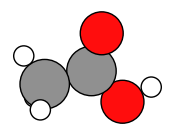

In [3]:
mol = plams.from_smiles("CC(O)=O")
for at in mol:
    at.properties = {}
mol = plams.preoptimize(mol)
plams.plot_molecule(mol)

## Continued Active Learning loop

To restart the AL loop, the simplest way is to load the `al_start_state` file containing the settings of the previous AL loop at initialization. 

In [4]:
start_state_path = require_companion_state(path)
al = ActiveLearningLoop.load_model(start_state_path)
if not isinstance(al.journey, SimpleActiveLearningJourney):
    raise TypeError(f"This tutorial requires SimpleActiveLearningJourney, got {type(al.journey)!r}.")

We should first set the start engine as the final engine of the previous AL loop.

In [5]:
al.start_engine = final_engine_al0

Then we change the `atomistic_system` in the `SimpleActiveLearningJourney` task:

In [6]:
al.journey.task.atomistic_system=SCMChemicalSystem.from_molecules(
    system_id="CC(O)=O",
    systems=mol,
)

We can import the previous training and validation dataset with the callback ImportStartEngineData.

In [7]:
from scm.active_learning.callbacks import ImportStartEngineData

# To be sure it is present:
if ImportStartEngineData not in list(map(type,al.callbacks)):
    al.callbacks.append(ImportStartEngineData())
print([c.type for c in al.callbacks])

['FolderManagerCallback', 'ALStateLogger', 'ALMinimalLogger', 'ImportStartEngineData', 'SkipIf', 'ManualStopper']


Uncomment these line to not import that data:

In [8]:
# if ImportStartEngineData in list(map(type,al.callbacks)):
#     idx_callback = list(map(type,al.callbacks)).index(ImportStartEngineData)
#     al.callbacks.pop(idx_callback)
#     print([c.type for c in al.callbacks])

In [9]:
import sys

ActiveLearningLoop.logging_config(
    clean_sinks="YES",
    new_sink=sys.stderr,
    level="INFO",
)

1

In [10]:
# If import_data_from_start_engine=True than we will import the dataset from previous engine
results_engine = al.run()

2026-04-21 15:59:20 | INFO     | AL Loop Folder: /home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_155920
2026-04-21 15:59:20 | INFO     | Train Val created: /home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_155920/train_validation_AL.db
2026-04-21 15:59:20 | INFO     | 
=================================== JourneyScheduler ===================================
AMSMDTask|CC(O)=O -> AMSTrajChecker|AMSTrajGetter
  MD NSteps    MD NSteps - Cumulative    MD SamplingFreq    MD MaxFrames    max_attempts
-----------  ------------------------  -----------------  --------------  --------------
        100                       100                  3              33              10
        216                       316                  7              30              10
        684                      1000                 22              31              10
       2162     

In [11]:
al.analysis.get_summary()

{'Reason': 'AL stopped: CONVERGED',
 'NSteps': 10,
 'Ninit': 19,
 'Nfinal': 29,
 'Tot[min]': 11}

In [12]:
pdf_plots = al.analysis.plot.save_to_pdf()

/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_155920/analysis.pdf


In [13]:
import webbrowser

webbrowser.open(str(pdf_plots))

True

### Experts - More complex rerun

In case of rerunning from a different stage than the `al_start_state` file, the API is not yet standardized. But you should double-check at least these component settings:
- `ActiveLearningLoop.callbaks`: especially the `FolderManagerCallback` responible for folders management.
- `ActiveLearningLoop.journey`
- `ActiveLearningLoop.result`

Remember if you want to rerun the loop in a different folder than before you should reset different attributes:

In [14]:
from scm.active_learning.callbacks import FolderManagerCallback

al.query_callback(FolderManagerCallback).root_dir
# al.query_callbacks(FolderManagerCallback)[0].root_dir.run_root = None

RootDir(run_root=PosixPath('/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_155920'), base_dir=PosixPath('/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns'), run_name=None, timestamp_format='%Y%m%d_%H%M%S')

You can restart journey with this method:

In [15]:
# al.journey.restart_journey()

## Next Step

This series of tutorials on journey Scheduler `SimpleActiveLearningJourney` is finished. 

You can now explore other scripts exaples in the folder: [active_learning/tutorials/scripts](../scripts) 